In [17]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 

In [18]:
import matplotlib.pyplot as plt 
#from spectres import spectres
import numpy as np
import jax.numpy as jnp 
import pickle 
import pandas as pd 

In [19]:
from sheap import Sheapectral 
from sheap.Utils.SpectralReaders import parallel_reader 

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
name_files = "DR16_[2.5, 2.75)"
with open(f"../pickle_spectra/{name_files}.pkl", "rb") as f:
    dict_spectra = pickle.load(f)
base_panda = pd.read_csv(f"../pickle_spectra/{name_files}.csv")

In [22]:
names = list(dict_spectra.keys())
spectra = np.stack([i["new"] for i in dict_spectra.values()])
z = np.stack([i["z"] for i in dict_spectra.values()])
coords = np.stack([i["coords"] for i in dict_spectra.values()])

In [23]:
base_panda.shape != len(names)

True

In [24]:
spectra[None,400,:].shape

(1, 4, 3809)

In [25]:
sheapspectral = Sheapectral(spectra,z=z,coords=coords,names=names)
#sheapspectral = Sheapectral(spectra[[400,401],:],z=z[[400,401]],coords=coords[[400,401]],names=names[400:402])

extinction correction will be do it, change 'extinction_correction' to done if you want to avoid this step
redshift correction will be do it, change 'redshift_correction' to done if you want to avoid this step


In [26]:
add_host_miles = {"z_include":None,"age_include":None}
#z_include: Optional[Union[tuple[float, float], list[float]]] = [-0.7, 0.22],
#age_include: Optional[Union[tuple[float, float], list[float]]] = [0.1, 10.0],
sheapspectral.makemodel(limits=(1100, 2750),n_broad=3,n_narrow=0,group_method=True,fe_mode ="none",continuum_profile="powerlaw"
                          ,add_winds=False,
                           add_outflow=False,
                           add_uncommon_narrow=False,
                           add_balmerhighorder_continuum = False , 
                           add_balmer_continuum = False,
                           add_BAL=False,verbose=True)

# for _,sp in enumerate(sheapspectral.complexbuild.complex_class.lines):
#     print(sp.profile)

In [27]:
sheapspectral.fitmodel(list_num_steps=[2_000],list_learning_rate=[1e-2],run_fit=True,add_penalty_function=False,
                         penalty_weight = 0.0,curvature_weight=0.0,smoothness_weight=0.0,max_weight=0.)

Fitting 500 spectra with 3809 wavelength pixels

STEP1 (step1) params to minimize 41
learning_rate: 0.01 num_steps: 2000 non_optimize_in_axis: 4


Time for step 'step1': 20.99 seconds
The entire process took 20.99 (0.04s by spectra)


In [28]:
sheapspectral.estimate_posteriors("montecarlo",num_samples=2)

Running Monte Carlo with JAX.,sample over the spectra using init params


Sampling obj:   0%|          | 0/2 [00:00<?, ?it/s]

Getting posterior-params:  35%|███▌      | 176/500 [00:43<01:20,  4.03it/s]


KeyboardInterrupt: 

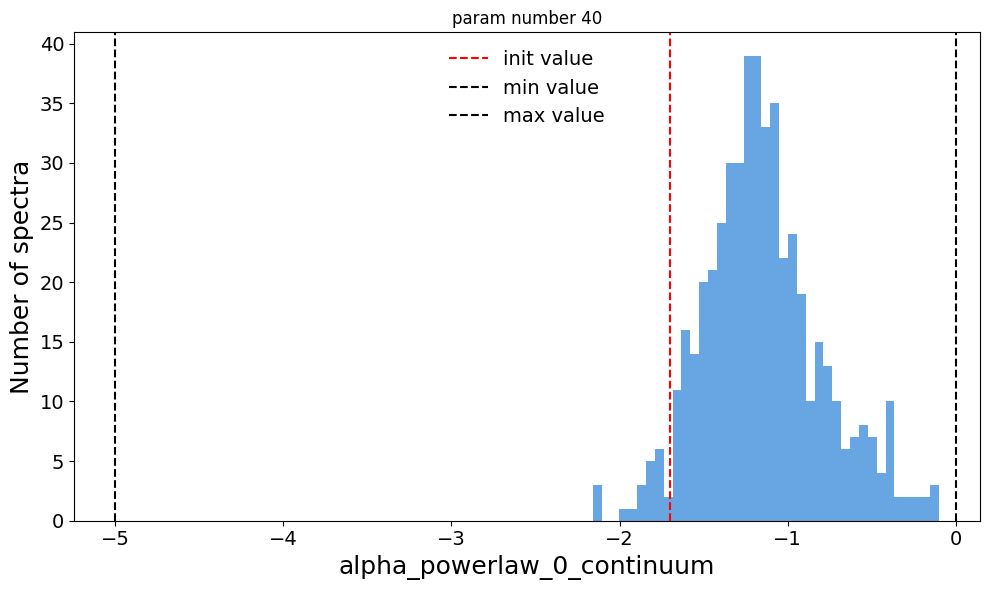

In [14]:
sheapspectral.plot_param_distribution("alpha_powerlaw_0_continuum")

In [54]:
np.argsort(sheapspectral.result.chi2_red)

Array([ 22, 197, 379, 167, 112,   2, 374, 300,   5, 179, 281, 241, 398,
       154, 123, 219,  68,   3,  37,  56, 314, 191,  75, 339,   1,  55,
        89, 356,  88, 174, 399, 235, 136, 223, 420, 350,  94, 260, 218,
       258, 411, 245,  91, 215, 192, 405, 169, 458,  24,  10, 204, 268,
       473, 164,  25,  33, 267, 139,  12, 253, 368, 443, 276, 203, 105,
       351, 291, 189, 240, 324, 338, 376, 242,  96,  71, 232, 233, 359,
        90, 106, 416, 414,  70, 353, 117,  32, 491,  82, 113, 210, 182,
        64,  17, 476, 317, 141,  73, 362,  38, 180, 239, 265, 426,  80,
        81, 424, 275, 286, 421,   9, 438,   8, 226, 489, 382,  97, 221,
       487, 372, 298, 418, 202, 256, 205, 451,  43, 330, 150,  57,  76,
       138, 456, 358, 144, 484, 348,  34, 217,  85, 397,  79, 470, 243,
       311, 155, 213, 483, 274, 349, 290, 386, 385,  11, 262, 104,  28,
       293, 247, 159, 310, 342, 335,  35, 419, 346,  59, 425, 266, 211,
       170, 133, 410, 287, 296, 334, 162, 168, 125, 228,  87, 42

In [69]:
sheapspectral.result.chi2_red[145]

Array(6.48447673, dtype=float64)

In [13]:
# sheapspectral.plot_param_distribution("logamp_feuvop_1_fe")

In [14]:
# sheapspectral.modelplot.plot(145)

In [15]:
# sheapspectral.modelplot.plot(30)

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


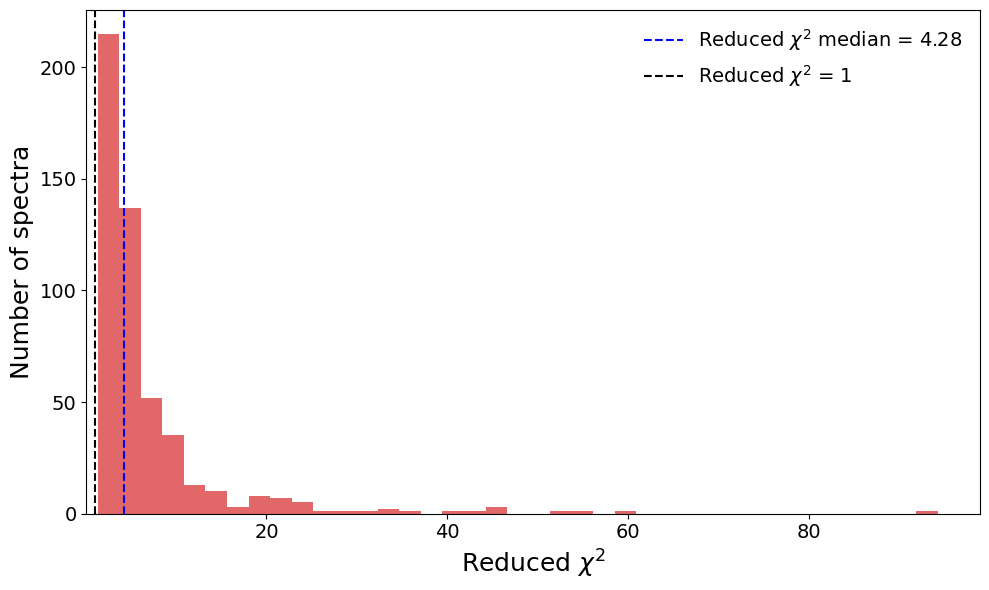

In [16]:
sheapspectral.plot_chi2

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


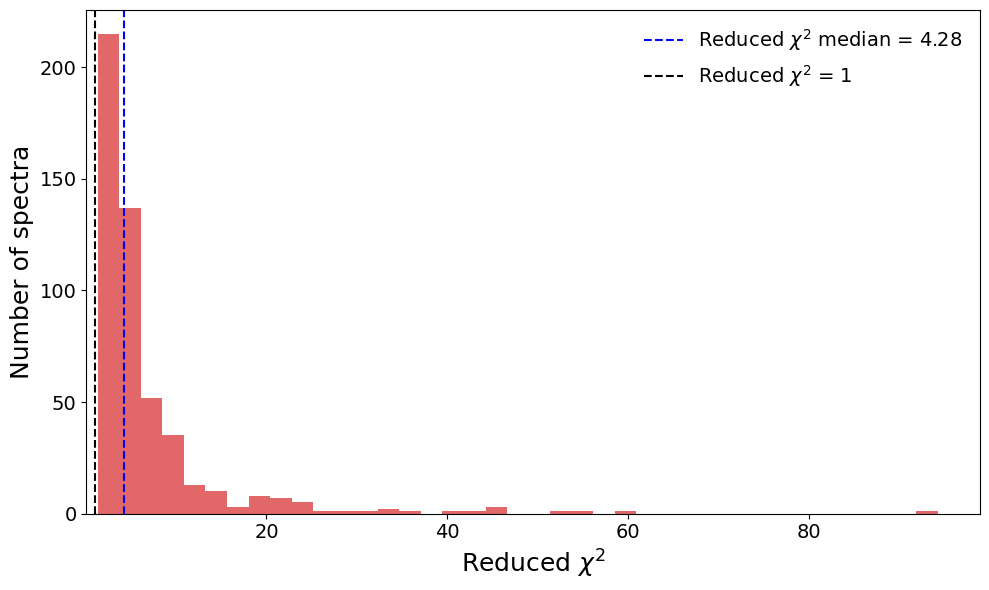

In [14]:
sheapspectral.plot_chi2

In [ ]:
sheapspectral.result.

Array([[ 1.61731263e-17,  3.22808650e-16,  4.54988347e-17, ...,
         3.92299914e+00, -1.62463818e+01, -1.41938925e+00],
       [ 5.43976408e-19,  9.53930160e-17,  3.96262982e-18, ...,
         3.96619344e+00, -1.67989120e+01, -1.58910632e+00],
       [ 1.98762299e-18,  1.63610528e-16,  2.77459671e-17, ...,
         3.96059275e+00, -1.67255211e+01, -1.28199339e+00],
       ...,
       [ 2.88101796e-18,  9.07145817e-16,  3.11452744e-16, ...,
         3.67688274e+00, -1.60759525e+01, -7.92005539e-01],
       [ 9.58730764e-19,  3.40412352e-19,  7.69241177e-16, ...,
         3.99809384e+00, -1.56603031e+01, -9.83688354e-01],
       [ 2.67087041e-17,  2.42213809e-16,  2.71544850e-17, ...,
         3.85283852e+00, -1.63086948e+01, -1.21980429e+00]],      dtype=float64)

In [31]:
# len(sheapspectral.result.sheapmodel.group_by("region")["broad"].lines)

In [ ]:

sheapspectral.save_to_pickle("wushen22_montecarlo_rachi.pkl")

Running Monte Carlo with JAX.,sample over the spectra using init params


Getting posterior-params: 100%|██████████| 500/500 [01:47<00:00,  4.67it/s]


Estimated pickle size: 116903.50 KB


In [46]:
sheapspectral.result.posterior["single"]["posterior_result"].keys()

dict_keys(['basic_params_combined_classical', 'basic_params', 'L_w', 'L_bol', 'F_cont', 'distances', 'extra_params_combined_classical', 'extra_params'])

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


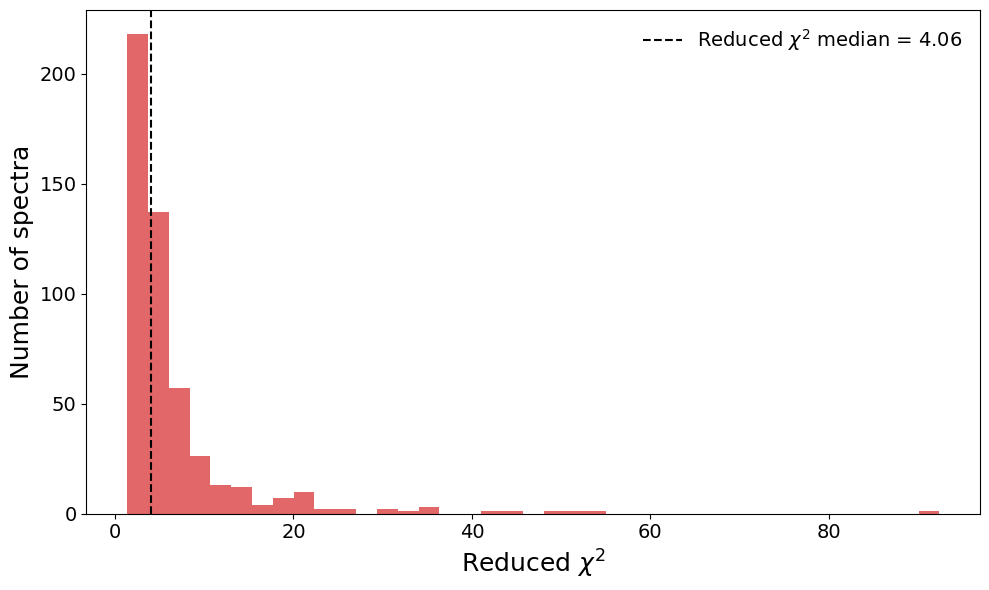

In [15]:
sheapspectral.plot_chi2

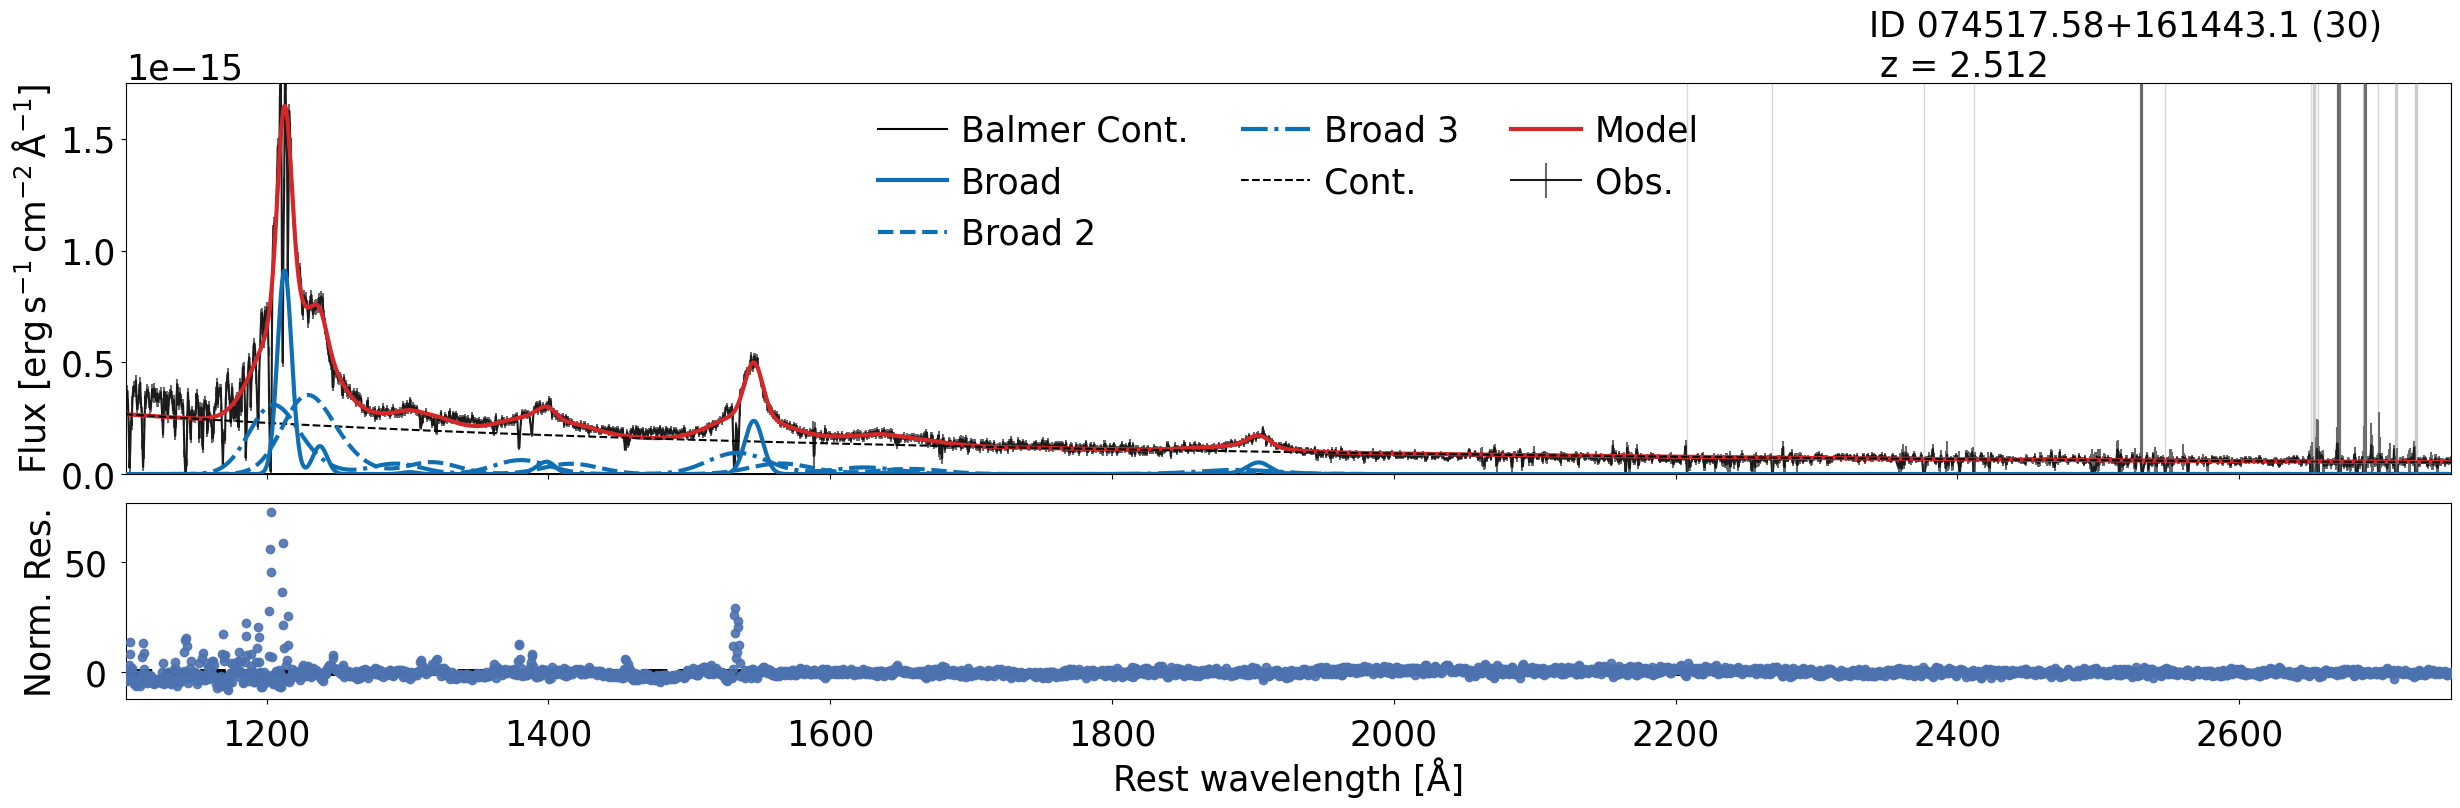

In [48]:
sheapspectral.plotter.plot(30,add_lines_name=False)

In [ ]:
#sheapspectral.estimate_posteriors(sampling_method="montecarlo",overwrite=True,summarize=False)


Estimated pickle size: 133457.57 KB


In [ ]:
# from sheap.ComplexSampler.ComplexSampler import ComplexSampler
# from sheap.ComplexParams.ComplexParams import ComplexParams
# from astropy.cosmology import FlatLambdaCDM
# draw_stest = ComplexSampler(sheap = sheapspectral).montecarlosampler(50, key_seed = 0,summarize=False,return_only_draws=True,frac_box_sigma=0.02,k_sigma=0.3)
# cm_per_mpc: float = 3.08568e24  
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
# d = cosmo.luminosity_distance(sheapspectral.z) * cm_per_mpc
# full_samples = draw_stest['082742.20+131609.6']["draws_phys"]
# complexparams = ComplexParams(samplerclass = sheapspectral.result,model=sheapspectral.spectral_model,spectra = sheapspectral.spectra,method="?",d=d)
# extracted_params = complexparams.extract_params(full_samples=full_samples,idx_obj=0,summarize=False)

Running Monte Carlo with JAX.,frac_box_sigma=0.02,k_sigma=0.3


Getting draws: 100%|██████████| 500/500 [00:02<00:00, 206.58it/s]
/share/cav/data/favila/smbh_mass/sheap/sheap/ComplexParams/Utils/Physical_functions.py:560: RuntimeWarning: invalid value encountered in divide
  local_extras["R_Fe"] = extras.get("flux_Fe",0)/flux_all[:, idxs]


In [18]:
draw_stest.keys()

dict_keys([np.str_('082742.20+131609.6'), np.str_('151428.16+115816.1'), np.str_('150058.56+110534.0'), np.str_('230437.64-005703.3'), np.str_('110424.76+093744.5'), np.str_('114411.76+202614.7'), np.str_('144314.70+271612.4'), np.str_('020459.54-020228.2'), np.str_('140759.07+051113.9'), np.str_('144450.92+255747.3'), np.str_('101003.46+415254.5'), np.str_('112409.16+305934.8'), np.str_('214129.38+111958.3'), np.str_('141658.12+310912.4'), np.str_('101326.47+320909.5'), np.str_('152740.04+101731.4'), np.str_('083231.61+211534.6'), np.str_('140210.14+451355.9'), np.str_('104904.48+495511.6'), np.str_('120026.40+182438.1'), np.str_('102752.46+200214.6'), np.str_('020629.33+004843.1'), np.str_('131428.30+232042.8'), np.str_('012212.20+350609.1'), np.str_('103641.47+573530.5'), np.str_('225832.98-003404.9'), np.str_('075154.02+224709.6'), np.str_('142814.84+513846.3'), np.str_('094259.05+432845.8'), np.str_('120553.15-001701.0'), np.str_('074517.58+161443.1'), np.str_('142654.17+195445.5'

In [18]:
sheapspectral.result.posterior[1]['111612.96+444225.7']["extra_combined_pyqso"]

{'CIV': {'VP06_CIV_1350': {'method': 'continuum',
   'wavelength': 1350,
   'vwidth_def': 'fwhm',
   'vwidth_kms': array([[4102.344 ],
          [4017.2954],
          [3618.2444],
          [4134.961 ],
          [4144.1484],
          [3234.1904],
          [4332.7627],
          [4895.322 ],
          [2832.636 ],
          [4271.804 ],
          [9422.248 ],
          [4201.942 ],
          [4190.227 ],
          [3324.695 ],
          [4003.6917],
          [2946.286 ],
          [2714.7815],
          [4071.4517],
          [4886.3706],
          [3451.5713],
          [3975.3733],
          [3433.6926],
          [3982.7896],
          [4963.058 ],
          [3785.1296],
          [4948.8164],
          [8048.5967],
          [2595.2502],
          [3899.0396],
          [3338.5825],
          [3717.8652],
          [3779.7683],
          [4063.9885],
          [4696.599 ],
          [3611.8203],
          [3509.1995],
          [3784.5156],
          [3534.6836],
          [371

In [392]:
# sheapspectral.result.complex_class.group_by("region")["broad"]

In [402]:
basic_params, L_w, L_bol, F_cont, combined_params, combined_pyqso,distances, extra_basic_params, extra_combined_params, extra_combined_pyqso,full_samples = sheapspectral.result.posterior[1][name_obj].values()

In [403]:
basic_params

{'broad': {'lines': ['OI+SiII',
   'Lyalpha',
   'NV',
   'CIII]',
   'SiIII]',
   'SiIV',
   'OIV]',
   'CIV',
   'HeIIa',
   'HeIIb',
   'AlIII',
   'OI+SiII',
   'Lyalpha',
   'NV',
   'CIII]',
   'SiIII]',
   'SiIV',
   'OIV]',
   'CIV',
   'HeIIa',
   'HeIIb',
   'OI+SiII',
   'Lyalpha',
   'NV',
   'CIII]',
   'SiIII]',
   'SiIV',
   'OIV]',
   'CIV',
   'HeIIa',
   'HeIIb'],
  'component': [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   2,
   2,
   2,
   2,
   2,
   2,
   2,
   2,
   2,
   2,
   3,
   3,
   3,
   3,
   3,
   3,
   3,
   3,
   3,
   3],
  'flux': array([[2.70952369e-16, 8.02243955e-15, 8.09400950e-16, 3.74665939e-16,
          1.49988318e-19, 3.92578829e-16, 2.87761007e-16, 1.57583504e-15,
          1.62181779e-16, 5.11918391e-16, 2.81820633e-20, 5.53200233e-15,
          2.27475003e-14, 1.91868366e-14, 5.03746046e-16, 1.18093093e-15,
          4.86021079e-15, 2.21526423e-16, 1.37794233e-14, 4.71176992e-15,
          7.34524155e-20, 6.69350813e

In [393]:
# # show all rows
# pd.set_option("display.max_rows", None)

# # (optionally) show all columns too
# pd.set_option("display.max_columns", None)
# sheapspectral.result_panda(0)

In [394]:
# from sheap.Profiles.Combine2 import SPAF_loglambda


# centers = [1548.0, 1551.0]                     # Å
# rules   = [(0, 1.0, 0), (1, 0.5, 0)]           # tie both to free amplitude 0

# G = SPAF_loglambda(centers, rules)             # composite profile

# x = jnp.linspace(1500.0, 1600.0, 4000)
# params = jnp.array([
#     1.0,        # amplitude0 (linear)
#     -800.0,     # shift_kms (shared Δv)
#     5000.0,     # fwhm_v_kms (shared)
# ], dtype=jnp.float32)

# y = G(x, params)                  

In [395]:
# plt.plot(y)

In [396]:
# 10**4

In [397]:
# pd.set_option('display.max_rows', None)
# sheapspectral.result_panda(200)

In [398]:
# sheapspectral.plotter.plot(90,add_lines_name=False)

In [399]:
sheapspectral.result.params[0]

Array([ 1.59162414e-16,  1.15918827e+00,  7.54059410e+00, -8.45793247e-01,
        6.34084629e-17,  1.84668641e-15,  1.10304541e-16,  1.53868167e-16,
        4.50306273e-17,  7.66478592e-17,  9.24429524e-17,  4.32985031e-16,
        2.46001177e-18,  3.56734915e-18,  1.88814712e-17, -2.03090576e+02,
        3.45167994e+00,  6.68979673e-17,  5.95479832e-16,  3.86161990e-17,
        1.98674986e-17,  5.49861405e-18,  6.61783864e-17,  4.39452853e-18,
        2.71614376e-16,  5.62427759e-17,  3.95182151e-19, -2.66215234e+03,
        3.89661217e+00,  4.77890662e-17,  4.39856930e-16,  1.31843444e-16,
        1.31575112e-18,  3.69429284e-18,  7.08618334e-18,  2.05204998e-17,
        6.86261859e-17,  4.55629676e-17,  1.87353307e-18,  2.82312598e+03,
        3.95612240e+00,  1.03622881e-16, -6.47728920e-01, -2.50000000e+00,
        5.50000000e+03], dtype=float64)

In [400]:
from uncertainties import unumpy
from sheap.ComplexSampler.Samplers.MonteCarloSampler import MonteCarloSampler

In [401]:
pm = sheapspectral.posteriors(sampling_method="none",overwrite=True,summarize=False,num_samples= 50)
pm.method = "?"

Nothing will run if you dont choose between sampling_method=montecarlo or sampling_method=mcmc or sampling_method=single


In [ ]:
MonteCarloSampler

sheap.ComplexSampler.Samplers.MonteCarloSampler.MonteCarloSampler

In [ ]:
pm

In [ ]:
#dic_posterior_params[name_i] = self.complexparams.extract_params(full_samples,n,summarize=summarize)
#dic_posterior_params[name_i].update({"samples_phys":full_samples})

In [ ]:


# params_1 = sheapspectral.result.posterior[1][sheapspectral.names[n_obj]]["samples_phys"][1]
# x = sheapspectral.spectra[n_obj,0,:]
# y = sheapspectral.spectra[n_obj,1,:]
# plt.plot(x,y,label = "data")
# for i in range(50):
# 	params_0 = sheapspectral.result.posterior[1][sheapspectral.names[n_obj]]["samples_phys"][i]
# 	plt.plot(x,sheapspectral.fitting_class.model(x ,params_0),alpha=0.1,color="k")
# #plt.plot(x,sheapspectral.fitting_class.model(x ,params_1),label = "params_1")
# plt.plot(x,sheapspectral.fitting_class.model(x ,sheapspectral.result.params[n_obj]),label = "best_model")
# plt.legend()

In [241]:
# sheapspectral.result.posterior[1][sheapspectral.names[n_obj]]["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["vwidth_kms"]

In [41]:
#complex_class_group_by_region = sheapspectral.result.complex_class.group_by("region")
n_obj = 0
name_obj = sheapspectral.names[n_obj]
# basic_params, L_w, L_bol, F_cont, combined_params, combined_pyqso,distances, extra_basic_params, extra_combined_params, extra_combined_pyqso,full_samples = sheapspectral.result.posterior[1][name_obj].values()
# jeje = MonteCarloSampler(estimator=pm).complexparams.extract_params(full_samples,n_obj,summarize=False)
# basic_params, L_w, L_bol, F_cont, combined_params, combined_pyqso,distances, extra_basic_params, extra_combined_params, extra_combined_pyqso = jeje.values()

In [42]:
sheapspectral.result.posterior[1][name_obj]["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["vwidth_kms"]

{'median': array([6332.58862305]),
 'err_minus': array([669.70561523]),
 'err_plus': array([3692.60926758])}

In [35]:
 q = np.nanpercentile(sheapspectral.result.posterior[1][name_obj]["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["vwidth_kms"], [16, 50, 84], axis=0)

In [36]:
q

array([[ 7036.88455078],
       [ 9154.265625  ],
       [11927.478125  ]])

In [309]:
# VP06_CIV_1350 =  pd.DataFrame([{"name": key,**values["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# VP06_CIV_1350_pyqso = base_panda.LOGMBH_CIV.values

In [310]:
from sheap.ComplexParams.Utils.Combine_profiles import combine_components,combine_fast_with_jacobian,combine_fast,GaussianSum,region_helper
from jax import vmap 

In [311]:
def gaussian(x, fwhm_c, amp_c, mu_c):
    """
    Gaussian profile using FWHM, amplitude, and mean.

    Parameters
    ----------
    x : array-like
        Input coordinates.
    fwhm_c : float
        Full width at half maximum.
    amp_c : float
        Gaussian amplitude.
    mu_c : float
        Gaussian mean (center).

    Returns
    -------
    numpy.ndarray
        Gaussian evaluated at x.
    """
    sigma = fwhm_c / (2 * np.sqrt(2 * np.log(2)))
    return amp_c * np.exp(-0.5 * ((x - mu_c) / sigma)**2)

In [312]:
# fwhm_A = (fwhm_c / c_kms) * mu_c
# plt.plot(x_wave,gaussian(x_wave,fwhm_A, amp_c, mu_c ),label="comb")
# plt.plot(*sheapspectral.spectra[n_obj,[0,1],:] - cont_group.combined_profile(sheapspectral.spectra[n_obj,[0,1],:][0],*cont_params),label="signal")
# for xd,(amb,mu,fwhm_kms) in enumerate(params_broad.reshape(3,3)):
#      fwhm = (fwhm_kms / c_kms) * mu
#      print(f"G{xd}",amb,mu,fwhm_kms)
#      plt.plot(x_wave,gaussian(x_wave,fwhm,amb,mu),label=f"G{xd}")
# plt.xlim(min(x_wave),max(x_wave))
# plt.legend()
# plt.show()


array([[6584.865 ],
       [7238.685 ],
       [4100.6675],
       [5011.5938],
       [4205.107 ],
       [3283.694 ],
       [5448.386 ],
       [5492.222 ],
       [2898.0105],
       [8109.5312],
       [5966.166 ],
       [5817.1123],
       [6952.505 ],
       [3411.3027],
       [6690.2256],
       [2977.462 ],
       [3164.5645],
       [5263.6226],
       [6199.182 ],
       [5677.2695],
       [7341.613 ],
       [4671.1626],
       [7358.1455],
       [5963.3315],
       [7923.9404],
       [6209.2666],
       [1506.2673],
       [3913.9192],
       [7253.895 ],
       [3231.9702],
       [5491.4424],
       [6778.935 ],
       [7036.136 ],
       [5818.7183],
       [8638.388 ],
       [6556.7363],
       [6585.6685],
       [4672.721 ],
       [6486.8506],
       [5924.669 ],
       [4402.105 ],
       [6300.9995],
       [6949.387 ],
       [7506.892 ],
       [6187.916 ],
       [7426.6143],
       [5710.1934],
       [4134.1577],
       [2828.0774],
       [7315.042 ]],

In [404]:
line = "CIV"
b_lines = np.array(basic_params["broad"]["lines"])
idx_b = np.where(np.char.lower(b_lines) == line.lower())[0]
lambda_ref = {"Halpha": 6564.61,  "Hbeta": 4862.68,"MgII": 2798.75,"CIV": 1549.48}[line]
params = full_samples
gg = GaussianSum(len(idx_b))
b_mu = jnp.asarray(basic_params["broad"]["center"])[:,idx_b].astype(jnp.float32)
b_sigma = jnp.asarray(basic_params["broad"]["fwhm"])[:,idx_b].astype(jnp.float32) /  (2.0 * jnp.sqrt(2.0 * jnp.log(2.0)))
b_amp   = jnp.asarray(basic_params["broad"]["amplitude"])[:,idx_b].astype(jnp.float32)    # (Nobj, NB)
_ = np.stack([b_amp, b_mu,b_sigma], axis=2)
line_params = jnp.array(_.transpose(0, 2, 1).reshape(_.shape[0], -1)).astype(jnp.float32)
left = np.min(b_mu - 3*b_sigma,axis=1)
right = np.max(b_mu + 3*b_sigma,axis=1)
disp = 1.e-4 #hyperparam 
npix = 50000 #int(max((right-left)/disp))  #(maybe it is 2 much)
wave = jnp.linspace(np.min(left), np.max(right), npix, dtype=jnp.float32)
model_sum = vmap(gg,in_axes=(None,0))(wave,line_params).astype(jnp.float32)
cont_map = region_helper(wave,"continuum" ,complex_class_group_by_region, params,on_axis_wavelength = None).squeeze().astype(jnp.float32)

i_peak     = jnp.argmax(model_sum, axis=1)            
#peak_A     = wave[i_peak]                         
half       = 0.5 * jnp.max(model_sum, axis=1)     
f          = model_sum - half[:, None]                 
#s          = jnp.sign(f)                               


cont_safe  = jnp.maximum(cont_map, 1e-30)
eqw       = jnp.trapezoid(model_sum / cont_safe, wave, axis=1) 


Nlam   = wave.shape[0]
idxs   = jnp.arange(Nlam - 1)                    
eps = 1e-30

def interp_at(k, f_row):
	# linear interpolation of zero crossing between k and k+1
	x0, x1 = wave[k],   wave[k + 1]
	y0, y1 = f_row[k],  f_row[k + 1]
	t = -y0 / (y1 - y0 + eps)
	return x0 + t * (x1 - x0)

def row_fwhm(f_row, i_peak_i):
	s_row      = jnp.sign(f_row)                  # (Nlam,)
	cross_mask = (s_row[:-1] * s_row[1:] ) < 0    # (Nlam-1,)

	left_cand  = jnp.where((idxs < i_peak_i) & cross_mask, idxs, -1)
	left_idx   = jnp.max(left_cand)               # -1 if none

	right_cand = jnp.where((idxs >= i_peak_i) & cross_mask, idxs, Nlam)
	right_idx  = jnp.min(right_cand)              # Nlam if none

	has_left   = left_idx  >= 0
	has_right  = right_idx <= (Nlam - 2)

	lam_L = jnp.where(has_left,  interp_at(left_idx,  f_row), jnp.nan)
	lam_R = jnp.where(has_right, interp_at(right_idx, f_row), jnp.nan)

	return lam_L, lam_R

lam_L, lam_R = vmap(row_fwhm, in_axes=(0, 0))(f.astype(jnp.float32), i_peak.astype(jnp.float32))   # (Nobj,), (Nobj,)
lambda_peak = wave[i_peak]


fwhm_kms_jeje = ((lam_R - lam_L) / lambda_peak) * c_kms   

sigma_eff = ((lam_R - lam_L) / lambda_peak) / (2.0 * jnp.sqrt(2.0 * jnp.log(2.0)))  # (Nobj,)
sigma_kms = fwhm_kms_jeje / (2.0 * np.sqrt(2.0 * np.log(2.0)))
mu_eff = lambda_peak 
Nobj = model_sum.shape[0]
peak_amp = model_sum[jnp.arange(Nobj), i_peak]  # (Nobj,)
amp_eff = peak_amp

# Pack parameters for a "single" Gaussian
eff_params = jnp.stack([(lam_R - lam_L),amp_eff, mu_eff], axis=1)  # (Nobj, 3)

In [405]:
np.median(fwhm_kms_jeje)

np.float32(4262.978)

np.float32(4260.16)

(1477.4705810546875, 1603.4942626953125)

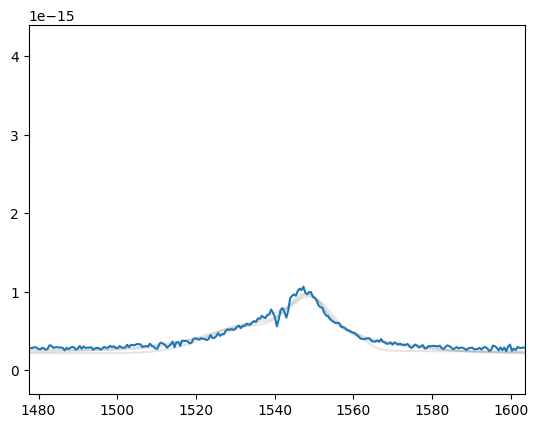

In [408]:
plt.plot(wave,model_sum.T+cont_map.T,alpha=0.1,c="k");
x = sheapspectral.spectra[n_obj,0,:]
y = sheapspectral.spectra[n_obj,1,:]
plt.plot(x,y)
plt.xlim(np.min(left), np.max(right))

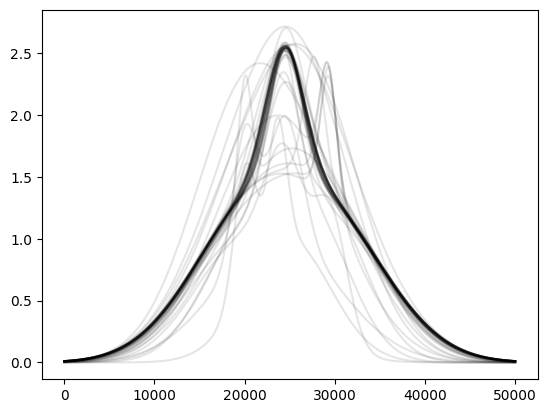

In [ ]:
line = "CIV"
b_lines = np.array(basic_params["broad"]["lines"])
idx_b = np.where(np.char.lower(b_lines) == line.lower())[0]
lambda_ref = {"Halpha": 6564.61,  "Hbeta": 4862.68,"MgII": 2798.75,"CIV": 1549.48}[line]
params = sheapspectral.result.params.astype(jnp.float32)[None,n_obj,:]
gg = GaussianSum(len(idx_b))
b_mu = jnp.asarray(basic_params["broad"]["center"]["median"])[None,idx_b].astype(jnp.float32)
b_sigma = jnp.asarray(basic_params["broad"]["fwhm"]["median"])[None,idx_b].astype(jnp.float32) /  (2.0 * jnp.sqrt(2.0 * jnp.log(2.0)))
b_amp   = jnp.asarray(basic_params["broad"]["amplitude"]["median"])[None,idx_b].astype(jnp.float32)    # (Nobj, NB)
_ = np.stack([b_amp, b_mu,b_sigma], axis=2)
line_params = jnp.array(_.transpose(0, 2, 1).reshape(_.shape[0], -1)).astype(jnp.float32)
left = np.min(b_mu - 3*b_sigma,axis=1)
right = np.max(b_mu + 3*b_sigma,axis=1)

disp = 1.e-4 #hyperparam 
npix = 50000 #int(max((right-left)/disp))  #(maybe it is 2 much)

wave = jnp.linspace(np.min(left), np.max(right), npix, dtype=jnp.float32)
model_sum = vmap(gg,in_axes=(None,0))(wave,line_params).astype(jnp.float32)
cont_map = region_helper(wave,"continuum" ,complex_class_group_by_region, params,on_axis_wavelength = None).squeeze().astype(jnp.float32)

i_peak     = jnp.argmax(model_sum, axis=1)            
#peak_A     = wave[i_peak]                         
half       = 0.5 * jnp.max(model_sum, axis=1)     
f          = model_sum - half[:, None]                 
#s          = jnp.sign(f)                               


cont_safe  = jnp.maximum(cont_map, 1e-30)
eqw       = jnp.trapezoid(model_sum / cont_safe, wave, axis=1) 


Nlam   = wave.shape[0]
idxs   = jnp.arange(Nlam - 1)                    
eps = 1e-30

def interp_at(k, f_row):
	# linear interpolation of zero crossing between k and k+1
	x0, x1 = wave[k],   wave[k + 1]
	y0, y1 = f_row[k],  f_row[k + 1]
	t = -y0 / (y1 - y0 + eps)
	return x0 + t * (x1 - x0)

def row_fwhm(f_row, i_peak_i):
	s_row      = jnp.sign(f_row)                  # (Nlam,)
	cross_mask = (s_row[:-1] * s_row[1:] ) < 0    # (Nlam-1,)

	left_cand  = jnp.where((idxs < i_peak_i) & cross_mask, idxs, -1)
	left_idx   = jnp.max(left_cand)               # -1 if none

	right_cand = jnp.where((idxs >= i_peak_i) & cross_mask, idxs, Nlam)
	right_idx  = jnp.min(right_cand)              # Nlam if none

	has_left   = left_idx  >= 0
	has_right  = right_idx <= (Nlam - 2)

	lam_L = jnp.where(has_left,  interp_at(left_idx,  f_row), jnp.nan)
	lam_R = jnp.where(has_right, interp_at(right_idx, f_row), jnp.nan)

	return lam_L, lam_R

lam_L, lam_R = vmap(row_fwhm, in_axes=(0, 0))(f.astype(jnp.float32), i_peak.astype(jnp.float32))   # (Nobj,), (Nobj,)
lambda_peak = wave[i_peak]


fwhm_kms_jeje = ((lam_R - lam_L) / lambda_peak) * c_kms   

sigma_eff = ((lam_R - lam_L) / lambda_peak) / (2.0 * jnp.sqrt(2.0 * jnp.log(2.0)))  # (Nobj,)
sigma_kms = fwhm_kms / (2.0 * np.sqrt(2.0 * np.log(2.0)))
mu_eff = lambda_peak 
Nobj = model_sum.shape[0]
peak_amp = model_sum[jnp.arange(Nobj), i_peak]  # (Nobj,)
amp_eff = peak_amp

# Pack parameters for a "single" Gaussian
eff_params = jnp.stack([(lam_R - lam_L),amp_eff, mu_eff], axis=1)  # (Nobj, 3)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices